#FBI Wanted List — Exploratory Data Analysis

##Overview
This project analyzes data pulled from the FBI's public "Wanted API" to answer the question:

**What patterns exist in the demographics, crime types, and reward structures of individuals on the FBI Wanted List?**

We examined 1,136 records and looked at crime categories, demographic breakdowns, reward amounts, physical profiles, and trends over time.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import datetime
import requests

## Data Collection
Data was pulled directly from the FBI's public API at https://api.fbi.gov/wanted/v1/list.
The API returns 20 records per page. We looped through all 57 pages to collect all 1,136 available records.

In [2]:
#pull data from FBI API

all_records = []

for page_number in range(1, 58):
    url = 'https://api.fbi.gov/wanted/v1/list'
    params = {'page': page_number}

    response = requests.get(url, params=params)
    data = response.json()

    #add the page's 20 records to main list
    all_records.extend(data['items'])

In [3]:
#convert to dataframe

df = pd.DataFrame(all_records)

df.head()

,files,age_range,uid,weight,occupations,field_offices,locations,reward_text,sex,hair,...,possible_states,modified,reward_max,race,height_max,place_of_birth,height_min,poster_classification,warning_message,pathId
0,[{'url': 'https://www.fbi.gov/wanted/law-enfor...,None,8b2461d815d5493886832689c2ef538d,210 pounds,"[Lang is a sailor who does odd jobs, such as f...","[honolulu, saltlakecity]",None,"The FBI is offering a reward of up to $5,000 f...",Male,brown,...,None,2026-03-19T13:08:55+00:00,0,white,68.0,"British Columbia, Canada",68.0,law-enforcement-assistance,SHOULD BE CONSIDERED AN ESCAPE RISK,https://api.fbi.gov/@wanted-person/8b2461d815d...
1,[{'url': 'https://www.fbi.gov/wanted/seeking-i...,None,dd2b306281994ec5a5ff4703dd69120d,None,None,[chicago],None,None,None,None,...,None,2026-03-16T00:13:42+00:00,0,None,NaN,None,NaN,information,None,https://api.fbi.gov/@wanted-person/dd2b3062819...
2,[{'url': 'https://www.fbi.gov/wanted/vicap/mis...,6 years old (at time of disappearance),b166d627e11149aa82c02d1533e3b650,60 pounds (at time of disappearance),None,None,None,None,Male,brown,...,None,2026-03-15T00:24:33+00:00,0,hispanic,54.0,None,54.0,default,None,https://api.fbi.gov/@wanted-person/b166d627e11...
3,[{'url': 'https://www.fbi.gov/wanted/counterin...,None,b953c05b852a4b719c0a152ef8a73ffd,None,[Electrical Engineer],[newyork],None,None,Male,black,...,None,2026-03-15T00:24:32+00:00,0,white,NaN,"Leningrad, Russia",NaN,default,None,https://api.fbi.gov/@wanted-person/b953c05b852...
4,[{'url': 'https://www.fbi.gov/wanted/vicap/mis...,44 (At time of disappearance),55b4a8a4053a4816befef81fe2b0c514,155 pounds,None,None,None,None,Male,black,...,None,2026-03-15T00:24:32+00:00,0,black,75.0,None,75.0,default,None,https://api.fbi.gov/@wanted-person/55b4a8a4053...


## Data Cleaning
Several columns required cleaning before analysis. Crime categories and field offices were stored as lists,
so we extracted the first value from each. Dates were stored as strings and needed to be converted.
We also created a new column to flag whether each listing includes a reward.

Several multi-word city names were also stored as concatenated strings after applying .title() . For example: "Newyork" instead of "New York". They were corrected using a dictionary replacement.

In [4]:
#grab the first crime per person
primary_crimes = []

for value in df['subjects']:
    if value:
        primary_crimes.append(value[0])
    else:
        primary_crimes.append('Unknown')

df['primary_crime'] = primary_crimes

In [5]:
#grab the first field office per person and capitalize it
primary_offices = []

for value in df['field_offices']:
    if value:
        primary_offices.append(value[0].title())
    else:
        primary_offices.append('Unknown')

df['primary_office'] = primary_offices
df["primary_office"] = df["primary_office"].replace("Newyork", "New York")

df["primary_office"] = df["primary_office"].replace({
    "Washingtondc": "Washington D.C.",
    "Losangeles": "Los Angeles",
    "Sanfrancisco": "San Francisco",
    "Stlouis": "St. Louis"
})

In [6]:
#convert date to datetime
df['publication'] = pd.to_datetime(df['publication'])

#pull year into its own column
df['year_posted'] = df['publication'].dt.year

In [7]:
#create a yes/no column for whether the listing has a reward
has_reward = []

for value in df['reward_min']:
    if value > 0:
        has_reward.append('Yes')
    else:
        has_reward.append('No')

df['has_reward'] = has_reward

In [8]:
df[['title', 'sex', 'race', 'primary_crime', 'primary_office', 'year_posted', 'has_reward']].head(10)

,title,sex,race,primary_crime,primary_office,year_posted,has_reward
0,DONALD STEVEN LANG,Male,white,Law Enforcement Assistance,Honolulu,2026,No
1,DALTON MESARCHIK,None,None,Seeking Information,Chicago,2023,No
2,"JESUS DE LA CRUZ - LYNN, MASSACHUSETTS",Male,hispanic,ViCAP Missing Persons,Unknown,2021,No
3,BORIS YAKOVLEVICH LIVSHITS,Male,white,Counterintelligence,New York,2022,No
4,"KENNETH EARL FOX - HOMESTEAD, FLORIDA",Male,black,ViCAP Missing Persons,Unknown,2025,No
5,DOUBLE MURDER,None,None,Seeking Information,St. Louis,2024,No
6,"IDA DEAN (RICHARDSON) ANDERSON - ANN ARBOR, MI...",Female,white,ViCAP Missing Persons,Unknown,2024,No
7,"BRYAN MATTHEW MCGEHRIN - TANEYTOWN, MARYLAND",Male,white,ViCAP Missing Persons,Unknown,2022,No
8,AMIT PATEL,None,None,Seeking Information,Atlanta,2025,No
9,"JOHN DOE - WATERLOO TOWNSHIP, MICHIGAN",Male,black,ViCAP Unidentified Persons,Unknown,2021,No


## Exploratory Analysis
Before visualizing, we take a look at the numeric columns and check for missing data.
Many columns have significant missing values; height, weight, age, and nationality
are frequently absent, which is expected given that many people are unidentified.

In [9]:
#summary stats
df.describe()

,age_min,age_max,publication,weight_min,weight_max,reward_min,reward_max,height_max,height_min,year_posted
count,223.000000,223.000000,1138,665.000000,665.000000,1138.000000,1.138000e+03,683.000000,683.000000,1138.000000
mean,31.179372,69.784753,2019-11-27 23:50:21.405975552,153.251128,158.550376,17135.325132,8.795251e+04,72.922401,69.389458,2019.389279
min,2.000000,4.000000,2010-06-29 13:35:00,17.000000,17.000000,0.000000,0.000000e+00,14.000000,24.000000,2010.000000
25%,20.500000,23.000000,2016-04-17 03:37:30,125.000000,130.000000,0.000000,0.000000e+00,64.000000,64.000000,2016.000000
50%,28.000000,32.000000,2021-02-23 09:47:30,150.000000,157.000000,0.000000,0.000000e+00,67.000000,67.000000,2021.000000
75%,40.000000,45.000000,2024-06-04 03:18:45,180.000000,180.000000,0.000000,0.000000e+00,70.000000,70.000000,2024.000000
max,85.000000,2020.000000,2026-03-13 07:37:00,350.000000,1976.000000,1000000.000000,4.999999e+06,2330.000000,2330.000000,2026.000000
std,14.592486,263.605849,NaN,42.929037,83.713030,128237.703784,6.425252e+05,121.038631,86.865609,5.085768


In [10]:
#count missing values
df.isnull().sum().sort_values(ascending=False)

,0
locations,1135
legat_names,1133
suspects,1132
additional_information,1120
complexion,1107
build,1076
possible_countries,1059
possible_states,1022
languages,981
occupations,945


###What types of crimes are most represented on the FBI Wanted List?

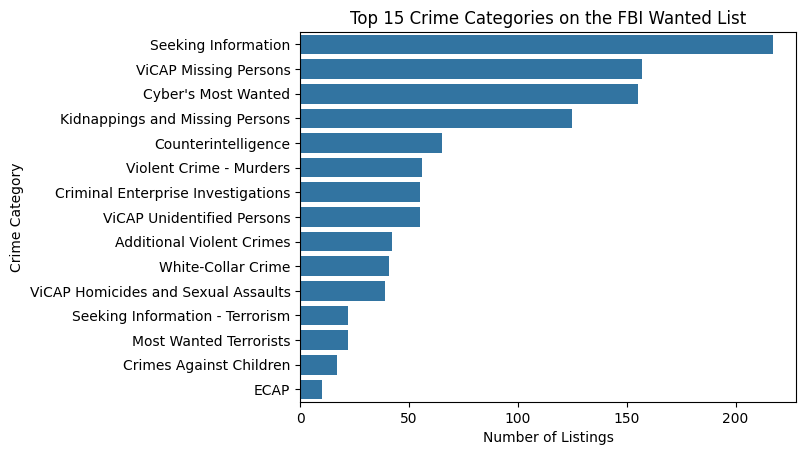

In [11]:
#count how many times each crime appears, keep + plot top 15 categories
crime_counts = df['primary_crime'].value_counts().head(15)

sns.barplot(x=crime_counts, y=crime_counts.index)
plt.title('Top 15 Crime Categories on the FBI Wanted List')
plt.xlabel('Number of Listings')
plt.ylabel('Crime Category')
plt.show()

Seeking Information is the largest category, which suggests that the FBI frequently uses the wanted list
to solicit tips from the public rather than just listing active fugitives. Cyber's Most Wanted and
ViCAP Missing Persons follow that and make up
a large share of the list. Traditional violent crime categories
are present but represent a smaller share than expected.

## Who is on the FBI Wanted List?

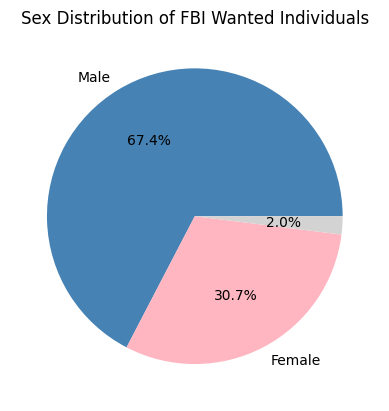

In [12]:
#count how many of each sex are on the list + plot
sex_counts = df['sex'].value_counts()

plt.pie(sex_counts, labels=sex_counts.index, autopct='%.1f%%', colors=['steelblue', 'lightpink', 'lightgray'])
plt.title('Sex Distribution of FBI Wanted Individuals')
plt.show()

The list is overwhelmingly male.
A small number of listings have no sex recorded, likely due to incomplete profiles.

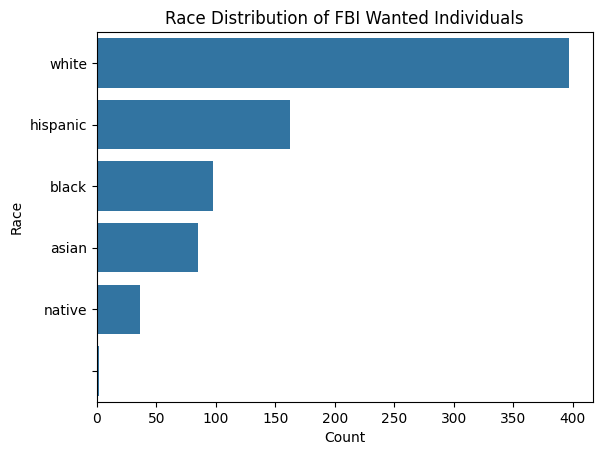

In [13]:
#count how many ppl of each race are on the list + plot
race_counts = df['race'].value_counts()

sns.barplot(x=race_counts.values, y=race_counts.index)
plt.title('Race Distribution of FBI Wanted Individuals')
plt.xlabel('Count')
plt.ylabel('Race')

plt.show()

White and Hispanic individuals make up the largest share of listings.

## Where are wanted individuals from?

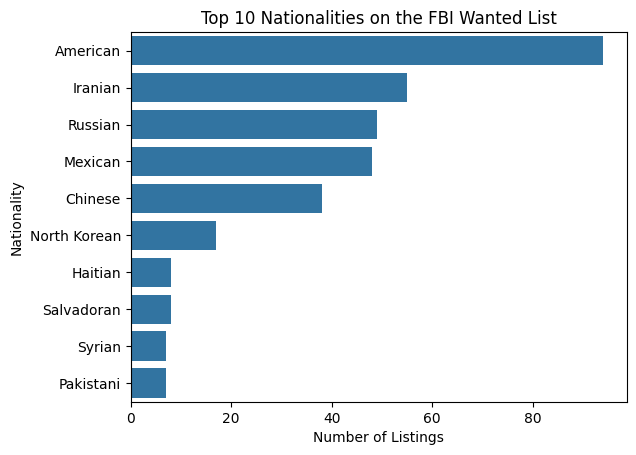

In [14]:
#count how many ppl from  each country, keep top 10
nationality_counts = df['nationality'].value_counts().head(10)

sns.barplot(x=nationality_counts.values, y=nationality_counts.index)
plt.title('Top 10 Nationalities on the FBI Wanted List')
plt.xlabel('Number of Listings')
plt.ylabel('Nationality')
plt.show()

Americans represent the largest group, but a lot of listings involve foreign nationals,
particularly from countries associated with counterintelligence investigations like China and Iran.

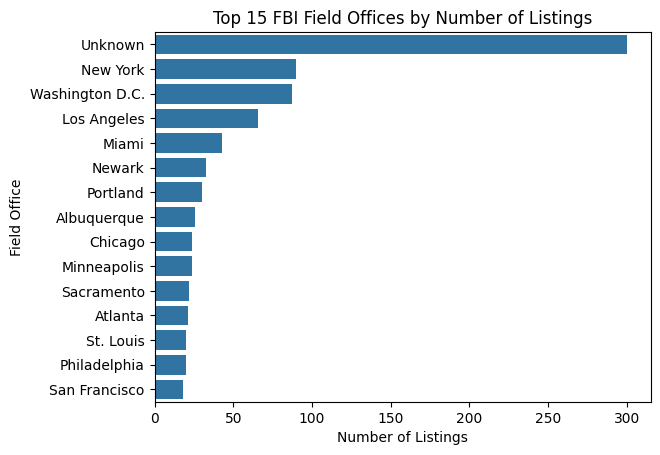

In [15]:
# count how many listings each field office has, keep top 15
office_counts = df["primary_office"].value_counts().head(15)

sns.barplot(x=office_counts.values, y=office_counts.index)
plt.title("Top 15 FBI Field Offices by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Field Office")
plt.show()

New York and Washington D.C. handle the largest share of listings among the known field offices, followed by Los Angeles and Miami. This concentration in major metropolitan areas is consistent with the FBI's focus on counterintelligence and cybercrime, which tend to involve international networks and are disproportionately handled by large coastal offices.

## Has the FBI Wanted List grown over time?

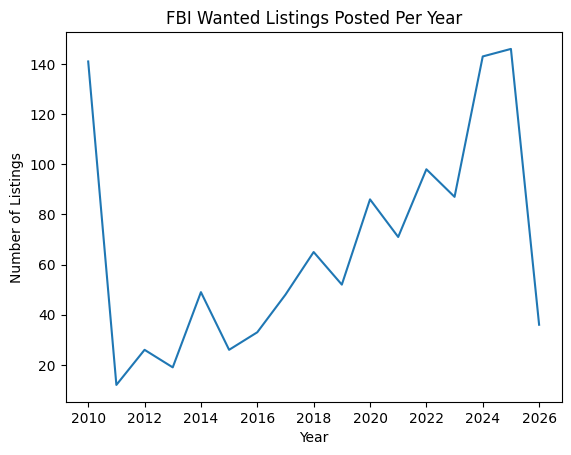

In [16]:
#count how many new listings per year and plot

yearly_counts = df['year_posted'].value_counts().sort_index()

sns.lineplot(x=yearly_counts.index, y=yearly_counts)
plt.title('FBI Wanted Listings Posted Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Listings')

plt.show()

The number of listings has grown steadily since 2010, with a notable spike in recent years.
This likely reflects both increased FBI resources dedicated to cybercrime and counterintelligence.

The spike in 2010 maybe reflects the initial launch of the FBI's digital wanted API, or when a large
batch of existing cases were uploaded at once.

## What factors are associated with higher rewards?

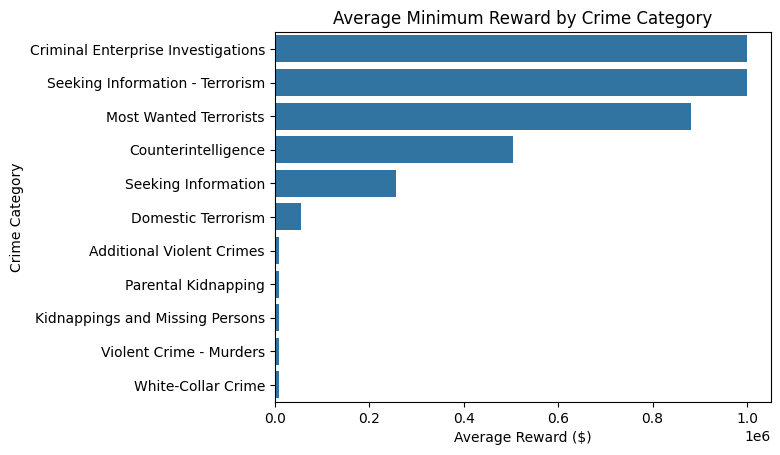

In [17]:
#only keep rows where a reward is offered
reward_df = df[df['reward_min'] > 0]

#calculate average reward for each crime type
mean_reward = reward_df.groupby('primary_crime')['reward_min'].mean().sort_values(ascending=False)

#plot
sns.barplot(x=mean_reward.values, y=mean_reward.index)
plt.title('Average Minimum Reward by Crime Category')
plt.xlabel('Average Reward ($)')
plt.ylabel('Crime Category')

plt.show()

"Criminal Enterprise Investigations" and "Seeking Information - Terrorism" both average the max reward of 1 million dollars. "Most Wanted Terrorists" follow closely at around 900k dollars, with "Counterintelligence" at around 500k. Categories like
violent crime and missing persons carry minimal or no rewards.

## How many listings actually include a reward?

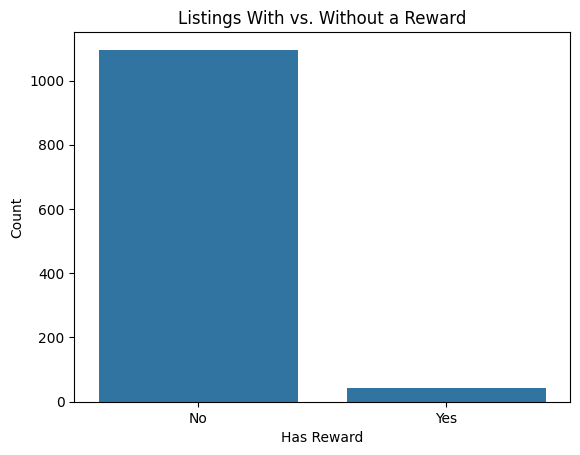

In [18]:
#count how many listings have a reward vs. not + plot
reward_share = df['has_reward'].value_counts()

sns.barplot(x=reward_share.index, y=reward_share)
plt.title('Listings With vs. Without a Reward')
plt.xlabel('Has Reward')
plt.ylabel('Count')
plt.show()

The majority of listings do not include a reward. Rewards tend to be reserved for high priority cases of national security.

## What does a typical wanted individual look like physically?

In [19]:
#only keep rows with realistic height and weight
height_weight_df = df[(df['height_min'] < 85) & (df['weight_min'] < 500) & (df['height_min'].notna()) & (df['weight_min'].notna())]

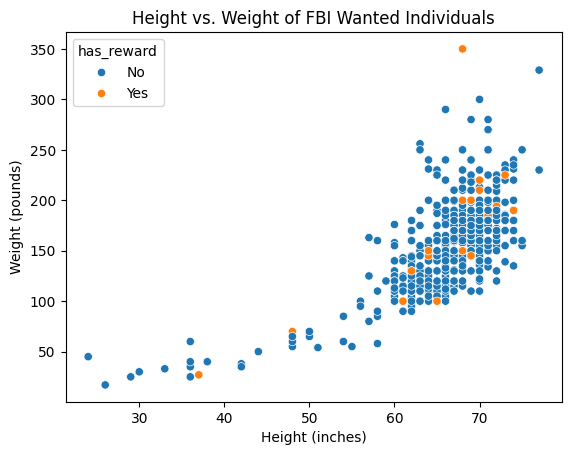

In [20]:
sns.scatterplot(data=height_weight_df, x='height_min', y='weight_min', hue='has_reward')
plt.title('Height vs. Weight of FBI Wanted Individuals')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.show()

The cluster between
60-75 inches and 140-220 pounds represents the typical adult male profile that dominates the list.
A small number of outliers with low height and weight mostly represent missing children cases.

Data cleaning was conducted to eliminate misinputs (10 feet tall, etc.)

## Conclusion
The FBI Wanted List is dominated by Seeking Information cases, cybercrime, and missing persons. The list serves a broader public engagement purpose beyond simply listing fugitives.
The list is overwhelmingly male, with White and Hispanic individuals making up the largest racial groups.
Reward amounts are highest for national security cases, with Criminal Enterprise Investigations and
terrorism-related listings averaging $1 million, the maximum reward offered. Physical profile data
clusters around a typical adult male range, with outliers likely representing missing children cases.